# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

El proyecto se llevara a cabo ya que se planea descubrir cual plan de prepago genera más ganancias y comprender el comportamiento de los usuarios con la ayuda de métodos estadísticos.

Plan de acción:
1. Visualización de los datos.
2. Corrección de errores en los datos.
3. Aplicar métodos estadísticos.

## Inicialización

In [1]:
# Cargar todas las librerías
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
calls_df = pd.read_csv("datasets/megaline_calls.csv")
internet_df = pd.read_csv("datasets/megaline_internet.csv")
messages_df = pd.read_csv("datasets/megaline_messages.csv")
plans_df = pd.read_csv("datasets/megaline_plans.csv")
users_df = pd.read_csv("datasets/megaline_users.csv")

## Preparar los datos

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
print(plans_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes
None


In [4]:
# Imprime una muestra de los datos para las tarifas

print(plans_df.head())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


Al realizar una inspección por el dataframe de tarifas me di cuenta de que la columna "usd_monthly_pay" y "usd_per_gb" son de tipo entero, para evitar problemas al realizar operaciones sería conveniente convertirlos a float, ya que se trata de datos sobre dinero y tendré que realizar operaciones con otras cantidades más adelante.

La solución sería convertir ambas columnas a float.

## Corregir datos

In [5]:
plans_df = plans_df.astype({"usd_monthly_pay": "float", "usd_per_gb": "float"})

print(plans_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      float64
 4   usd_per_gb             2 non-null      float64
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(4), int64(3), object(1)
memory usage: 260.0+ bytes
None


## Enriquecer los datos

## Usuarios/as

In [6]:
# Imprime la información general/resumida sobre el DataFrame de usuarios

print(users_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None


In [7]:
# Imprime una muestra de datos para usuarios

print(users_df.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


Al realizar una impresión de una muestra de los datos puede ver que en la columan "city" se encuentran la ciudad y la región.
Para análisis posteriores sería conveniente que se separarán estos dos datos.

### Corregir los datos

In [8]:
users_df["reg_date"] = pd.to_datetime(users_df["reg_date"])
users_df["churn_date"] = pd.to_datetime(users_df["churn_date"])

print(users_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
None


### Enriquecer los datos

In [9]:
users_df["region"] = users_df["city"].str.split(',', expand=True)[1].str.replace(' MSA', '', regex=False).str.strip()

print(users_df.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan churn_date region  
0 2018-12-24  ultimate        NaT     GA  
1 2018-08-13      surf        NaT     WA  
2 2018-10-21      surf        NaT     NV  
3 2018-01-28      surf        NaT     OK  
4 2018-05-23      surf        NaT     WA  


## Llamadas

In [10]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas

print(calls_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None


In [11]:
# Imprime una muestra de datos para las llamadas

calls_df.head(15)

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
5,1000_388,1000,2018-12-31,2.20
6,1000_510,1000,2018-12-27,5.75
7,1000_521,1000,2018-12-28,14.18
8,1000_530,1000,2018-12-28,5.77
9,1000_544,1000,2018-12-26,4.40


Pude observar que el tipo de dato de la columna "call_date" es string pero se trata de una fecha, por lo que, para evitar problemas con el análisis posterior, se necesitó convertirlo a tipo de datos datetime.

También observé que la columna duration está en un tipo de dato float para facilitar el análisis; veo que sería conveniente convertirlo a entero, ya que el diccionario de datos menciona que se trata de la duración en minutos de la llamada.

Redondee los números al número entero más cercano para arriba.

### Corregir los datos

In [12]:
calls_df["call_date"] = pd.to_datetime(calls_df["call_date"])

calls_df["duration"] = np.ceil(calls_df["duration"]).astype("int")

print(calls_df.info())
print(calls_df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 4.2+ MB
None
         id  user_id  call_date  duration
0   1000_93     1000 2018-12-27         9
1  1000_145     1000 2018-12-27        14
2  1000_247     1000 2018-12-27        15
3  1000_309     1000 2018-12-28         6
4  1000_380     1000 2018-12-30         5


### Enriquecer los datos

In [13]:
calls_df["month"] = calls_df["call_date"].dt.month

print(calls_df.head())

         id  user_id  call_date  duration  month
0   1000_93     1000 2018-12-27         9     12
1  1000_145     1000 2018-12-27        14     12
2  1000_247     1000 2018-12-27        15     12
3  1000_309     1000 2018-12-28         6     12
4  1000_380     1000 2018-12-30         5     12


## Mensajes

In [14]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

print(messages_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


In [15]:
# Imprime una muestra de datos para los mensajes

print(messages_df.head(15))

          id  user_id message_date
0   1000_125     1000   2018-12-27
1   1000_160     1000   2018-12-31
2   1000_223     1000   2018-12-31
3   1000_251     1000   2018-12-27
4   1000_255     1000   2018-12-26
5   1000_346     1000   2018-12-29
6   1000_386     1000   2018-12-30
7   1000_413     1000   2018-12-31
8   1000_502     1000   2018-12-27
9   1000_525     1000   2018-12-28
10  1000_567     1000   2018-12-25
11    1001_1     1001   2018-11-14
12    1001_2     1001   2018-08-17
13    1001_5     1001   2018-12-05
14    1001_7     1001   2018-11-28


Veo que la columna "message_date" es de tipo string pero se trata de fechas.
Solución: convertirlo a datetime.

### Corregir los datos

In [16]:
messages_df["message_date"] = pd.to_datetime(messages_df["message_date"])

print(messages_df.dtypes)

id                      object
user_id                  int64
message_date    datetime64[ns]
dtype: object


### Enriquecer los datos

In [17]:
print(messages_df.head())
print()

messages_df["month"] = messages_df.message_date.dt.month

print(messages_df.head())

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26

         id  user_id message_date  month
0  1000_125     1000   2018-12-27     12
1  1000_160     1000   2018-12-31     12
2  1000_223     1000   2018-12-31     12
3  1000_251     1000   2018-12-27     12
4  1000_255     1000   2018-12-26     12


## Internet

In [18]:
# Imprime la información general/resumida sobre el DataFrame de internet

print(internet_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None


In [19]:
# Imprime una muestra de datos para el tráfico de internet

print(internet_df.head(15))

          id  user_id session_date  mb_used
0    1000_13     1000   2018-12-29    89.86
1   1000_204     1000   2018-12-31     0.00
2   1000_379     1000   2018-12-28   660.40
3   1000_413     1000   2018-12-26   270.99
4   1000_442     1000   2018-12-27   880.22
5     1001_0     1001   2018-08-24   284.68
6     1001_3     1001   2018-12-09   656.04
7     1001_4     1001   2018-11-04    16.97
8    1001_10     1001   2018-11-27   135.18
9    1001_15     1001   2018-12-13   761.92
10   1001_16     1001   2018-10-28   501.53
11   1001_17     1001   2018-09-05   727.29
12   1001_24     1001   2018-09-05   622.03
13   1001_25     1001   2018-10-14   310.43
14   1001_26     1001   2018-09-17     0.00


Veo que en la columna "session_date" es de tipo string, pero contiene fechas así es que sería mejor convertirlos a tipo de datos datetime.
También veo que la columna "mb_used" es de tipo flaot pero para facilitar los análisis posteriores sería conveniente convertirlos a entero.

### Corregir los datos

In [20]:
internet_df["session_date"] = pd.to_datetime(internet_df["session_date"])

internet_df["mb_used"] = internet_df["mb_used"].round().astype("int")

print(internet_df.dtypes)

id                      object
user_id                  int64
session_date    datetime64[ns]
mb_used                  int64
dtype: object


### Enriquecer los datos

In [21]:
internet_df["month"] = internet_df["session_date"].dt.month

print(internet_df.head())

         id  user_id session_date  mb_used  month
0   1000_13     1000   2018-12-29       90     12
1  1000_204     1000   2018-12-31        0     12
2  1000_379     1000   2018-12-28      660     12
3  1000_413     1000   2018-12-26      271     12
4  1000_442     1000   2018-12-27      880     12


## Estudiar las condiciones de las tarifas

In [22]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

print(plans_df.head())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0             20.0        10.0             0.03            0.03      surf  
1             70.0         7.0             0.01            0.01  ultimate  


## Agregar datos por usuario

In [23]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

calls_number = calls_df.groupby(["user_id", "month"]).size().to_frame("number_calls")

print(calls_number)

               number_calls
user_id month              
1000    12               16
1001    8                27
        9                49
        10               65
        11               64
...                     ...
1498    12               39
1499    9                41
        10               53
        11               45
        12               65

[2258 rows x 1 columns]


In [24]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

min_per_user_month = calls_df.groupby(["user_id", "month"])["duration"].sum().to_frame("number_minutes")

print(min_per_user_month)

               number_minutes
user_id month                
1000    12                124
1001    8                 182
        9                 315
        10                393
        11                426
...                       ...
1498    12                339
1499    9                 346
        10                385
        11                308
        12                496

[2258 rows x 1 columns]


In [25]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

num_mess_send_user = messages_df.groupby(["user_id", "month"]).size().to_frame("number_messages")

print(num_mess_send_user)

               number_messages
user_id month                 
1000    12                  11
1001    8                   30
        9                   44
        10                  53
        11                  36
...                        ...
1496    9                   21
        10                  18
        11                  13
        12                  11
1497    12                  50

[1806 rows x 1 columns]


In [26]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

print(internet_df.head())

internet_traffic_per_user = internet_df.groupby(["user_id", "month"])["mb_used"].sum().to_frame("internet_traffic")

print(internet_traffic_per_user)

         id  user_id session_date  mb_used  month
0   1000_13     1000   2018-12-29       90     12
1  1000_204     1000   2018-12-31        0     12
2  1000_379     1000   2018-12-28      660     12
3  1000_413     1000   2018-12-26      271     12
4  1000_442     1000   2018-12-27      880     12
               internet_traffic
user_id month                  
1000    12                 1901
1001    8                  6922
        9                 13318
        10                22332
        11                18507
...                         ...
1498    12                23142
1499    9                 12985
        10                19493
        11                16815
        12                22056

[2277 rows x 1 columns]


In [27]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

from functools import reduce

dfs = [calls_number, min_per_user_month, num_mess_send_user, internet_traffic_per_user]

# user_consumption_per_month = pd.merge(dfs, how="outer", )

user_consumption_per_month = reduce(lambda left, right: left.merge(right, on=["user_id", "month"]), dfs)

user_consumption_per_month = user_consumption_per_month.reset_index()

print(user_consumption_per_month.head(20))

    user_id  month  number_calls  number_minutes  number_messages  \
0      1000     12            16             124               11   
1      1001      8            27             182               30   
2      1001      9            49             315               44   
3      1001     10            65             393               53   
4      1001     11            64             426               36   
5      1001     12            56             412               44   
6      1002     10            11              59               15   
7      1002     11            55             386               32   
8      1002     12            47             384               41   
9      1003     12           149            1104               50   
10     1004      5            21             193                7   
11     1004      6            44             275               18   
12     1004      7            49             381               26   
13     1004      8            49  

In [28]:
# Añade la información de la tarifa

user_consumption_per_month = user_consumption_per_month.merge(users_df[["user_id", "plan"]], on="user_id", how="left")

print(user_consumption_per_month.head())

   user_id  month  number_calls  number_minutes  number_messages  \
0     1000     12            16             124               11   
1     1001      8            27             182               30   
2     1001      9            49             315               44   
3     1001     10            65             393               53   
4     1001     11            64             426               36   

   internet_traffic      plan  
0              1901  ultimate  
1              6922      surf  
2             13318      surf  
3             22332      surf  
4             18507      surf  


In [29]:
# Calcula el ingreso mensual para cada usuario

# Surf plan
SURF_MEMBERSHIP = 20
SURF_MINUTES_INCLUDED = 500
SURF_SMS_INCLUDED = 50
SURF_GB_INCLUDED = 15
SURF_MINUTE_EXCEEDING = 3 / 100
SURF_SMS_EXCEEDING = 3 / 100
SURF_GB_EXCEEDING = 10

# Ultimate plan
ULTIMATE_MEMBERSHIP = 70
ULTIMATE_MINUTES_INCLUDED = 3000
ULTIMATE_SMS_INCLUDED = 1000
ULTIMATE_GB_INCLUDED = 30
ULTIMATE_MINUTE_EXCEEDING = 1 / 100
ULTIMATE_SMS_EXCEEDING = 1 / 100
ULTIMATE_GB_EXCEEDING = 7

# Función
def calculate_income(row):
    minutes_exceeding = 0
    sms_exceeding = 0
    gb_exceeding = 0
    income = 0

    if row["plan"] == "surf":
        # Calculando los excedentes
        if (row["number_minutes"] >= SURF_MINUTES_INCLUDED):
            minutes_exceeding = row["number_minutes"] - SURF_MINUTES_INCLUDED
        if (row["number_messages"] >= SURF_SMS_INCLUDED):
            sms_exceeding = row["number_messages"] - SURF_SMS_INCLUDED
        
        gb_rounded = np.ceil(row["internet_traffic"] / 1024)
        if (gb_rounded >= SURF_GB_INCLUDED):
            gb_exceeding = gb_rounded - SURF_GB_INCLUDED

        # Calculando el costo de los excedentes
        minutes_exceeding_cost = minutes_exceeding * SURF_MINUTE_EXCEEDING
        sms_exceeding_cost = sms_exceeding * SURF_SMS_EXCEEDING
        gb_exceeding_cost = gb_exceeding * SURF_GB_EXCEEDING

        exceedings_cost = minutes_exceeding_cost + sms_exceeding_cost + gb_exceeding_cost

        # Sumando la tarifa
        income = exceedings_cost + SURF_MEMBERSHIP

    if row["plan"] == "ultimate":
        # Calculando los excedentes
        if (row["number_minutes"] >= ULTIMATE_MINUTES_INCLUDED):
            minutes_exceeding = row["number_minutes"] - ULTIMATE_MINUTES_INCLUDED
        if (row["number_messages"] >= ULTIMATE_SMS_INCLUDED):
            sms_exceeding = row["number_messages"] - ULTIMATE_SMS_INCLUDED

        gb_rounded = np.ceil(row["internet_traffic"] / 1024)
        if (gb_rounded >= ULTIMATE_GB_INCLUDED):   
            gb_exceeding = gb_rounded - ULTIMATE_GB_INCLUDED

        # Calculando el costo de los excedentes
        minutes_exceeding_cost = minutes_exceeding * ULTIMATE_MINUTE_EXCEEDING
        sms_exceeding_cost = sms_exceeding * ULTIMATE_SMS_EXCEEDING
        gb_exceeding_cost = gb_exceeding * ULTIMATE_GB_EXCEEDING

        exceedings_cost = minutes_exceeding_cost + sms_exceeding_cost + gb_exceeding_cost

        income = exceedings_cost + ULTIMATE_MEMBERSHIP
    
    # DEBUG
    if (row["user_id"] == 1001 and row["month"] == 10):
        print(f"Minutos excedidos: {minutes_exceeding}")
        print(f"sms excedidos: {sms_exceeding}")
        print(f"gb excedidos: {gb_exceeding}")
        print(f"Income {income}")
        print()

    return income

user_consumption_per_month["income"] = user_consumption_per_month.apply(calculate_income, axis=1)

print(user_consumption_per_month.head())

Minutos excedidos: 0
sms excedidos: 3
gb excedidos: 7.0
Income 90.09

   user_id  month  number_calls  number_minutes  number_messages  \
0     1000     12            16             124               11   
1     1001      8            27             182               30   
2     1001      9            49             315               44   
3     1001     10            65             393               53   
4     1001     11            64             426               36   

   internet_traffic      plan  income  
0              1901  ultimate   70.00  
1              6922      surf   20.00  
2             13318      surf   20.00  
3             22332      surf   90.09  
4             18507      surf   60.00  


## Estudia el comportamiento de usuario

### Llamadas

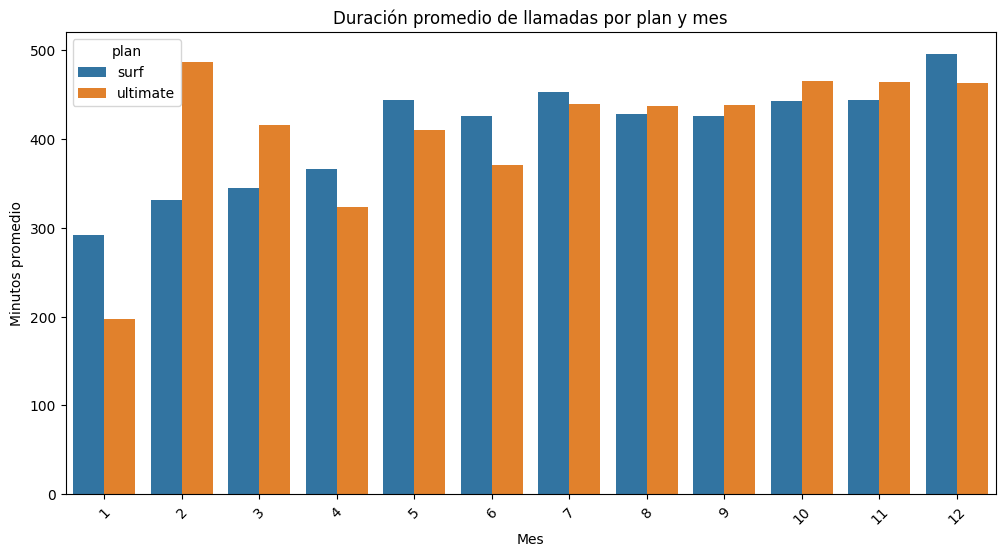

In [30]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

avg_duration = user_consumption_per_month.groupby(["plan", "month"])["number_minutes"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_duration, x="month", y="number_minutes", hue="plan")
plt.title("Duración promedio de llamadas por plan y mes")
plt.xlabel("Mes")
plt.ylabel("Minutos promedio")
plt.xticks(rotation=45)
plt.show()

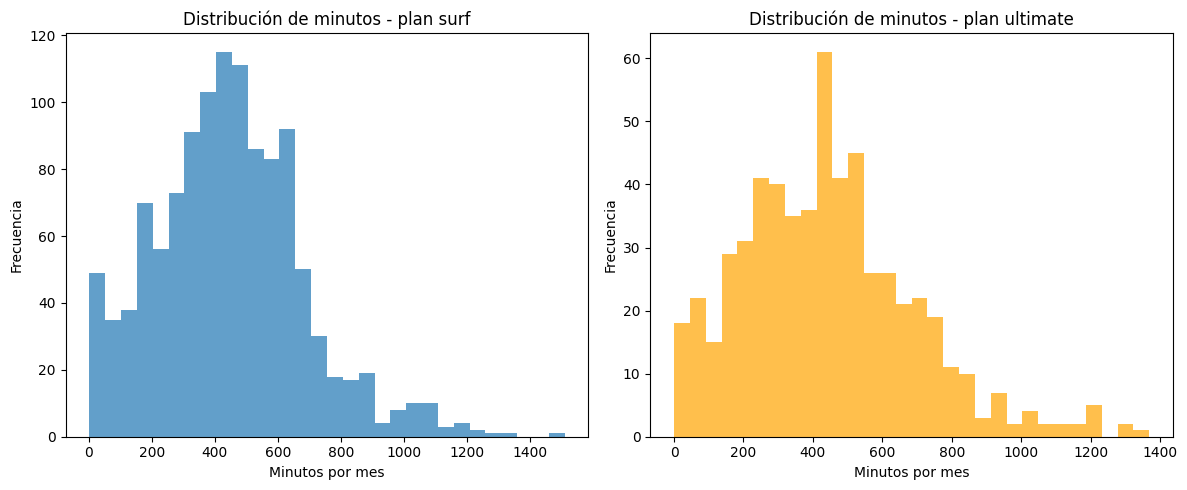

In [31]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
surf_minutes = user_consumption_per_month[
    user_consumption_per_month["plan"] == "surf"
]["number_minutes"]
plt.hist(surf_minutes, bins=30, alpha=0.7, label="Surf")
plt.title("Distribución de minutos - plan surf")
plt.xlabel("Minutos por mes")
plt.ylabel("Frecuencia")

plt.subplot(1, 2, 2)
ultimate_minutes = user_consumption_per_month[
    user_consumption_per_month["plan"] == "ultimate"
]["number_minutes"]
plt.hist(ultimate_minutes, bins=30, alpha=0.7, label="Ultimate", color="orange")
plt.title("Distribución de minutos - plan ultimate")
plt.xlabel("Minutos por mes")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [32]:
# Calcula la media y la varianza de la duración mensual de llamadas.

stats_by_plan = user_consumption_per_month.groupby("plan")["number_minutes"].agg(["mean", "var"]).round(2)
print("Estadísticas de minutos por plan:")
print(stats_by_plan)

Estadísticas de minutos por plan:
            mean       var
plan                      
surf      445.78  55321.41
ultimate  442.51  62288.40


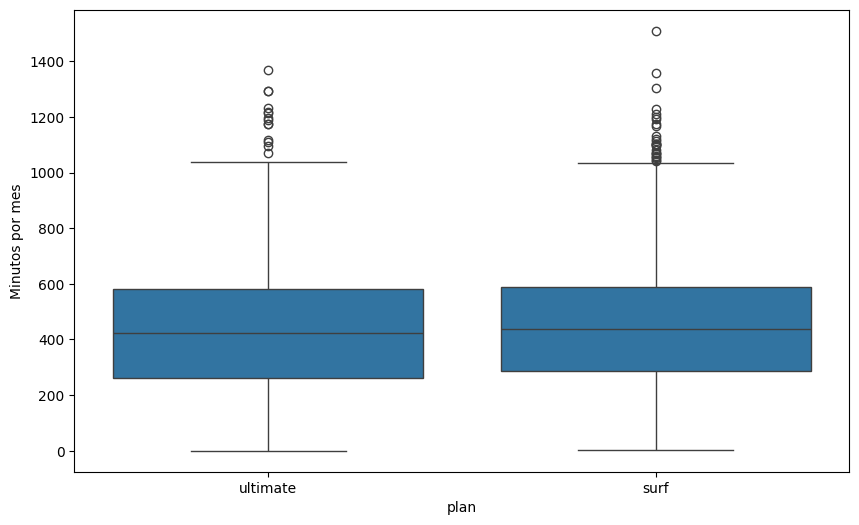

In [33]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=user_consumption_per_month,
    x="plan",
    y="number_minutes",
)
plt.xlabel("plan")
plt.ylabel("Minutos por mes")
plt.show()

En el análisis del comportamiento de los usuarios, observe:
- Los usuarios del plan Surf en promedio no superan el límite del plan.
- Los usuarios del plan Ultimate no se acercan a los minutos incluidos del plan, utilizan menos, similar al plan Surf.
- También veo que no existe mucha diferencia en el uso de minutos en ambos planes, auque los usuarios del plan Ultimate cuentan con muchos más minutos al mes es ligero el incremento.
- Observo también que ambos planes tiene una media casí similar.
- Varianza diferente, que nos dice que los usuarios del plan Ultimate están minimamenete más dispersos, pero es de que esperarse ya que es el plan con más minutos incluidos.
- Los usuarios tanto de Ultimate como los de Surf tiene similares comportamientos, pero los Ultimate es el que contiene ligeramente más outliers.

### Mensajes

        plan  month  number_messages
0       surf      1        21.000000
1       surf      2        21.600000
2       surf      3        21.937500
3       surf      4        24.685714
4       surf      5        33.547170
5       surf      6        32.742857
6       surf      7        34.786517
7       surf      8        37.302521
8       surf      9        38.585034
9       surf     10        41.475138
10      surf     11        40.087156
11      surf     12        47.686992
12  ultimate      1        20.666667
13  ultimate      2        27.800000
14  ultimate      3        34.714286
15  ultimate      4        28.937500
16  ultimate      5        44.333333
17  ultimate      6        37.135135
18  ultimate      7        41.212766
19  ultimate      8        47.929825
20  ultimate      9        45.901408
21  ultimate     10        47.488636
22  ultimate     11        47.656863
23  ultimate     12        53.744000 



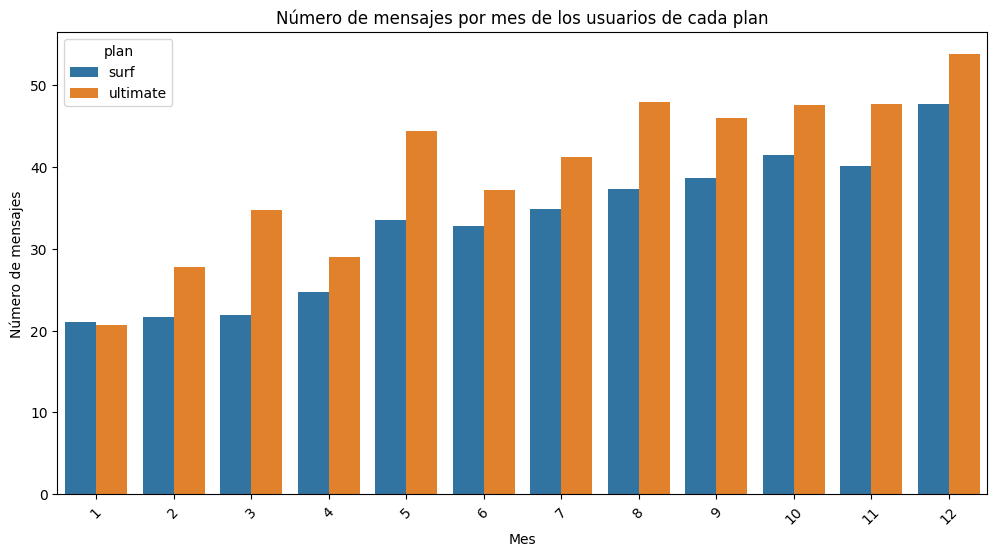

In [34]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

number_messages = (
    user_consumption_per_month
        .groupby(["plan", "month"])["number_messages"]
        .mean()
        .reset_index()
)

print(number_messages, "\n")

plt.figure(figsize=(12, 6))
sns.barplot(data=number_messages, x="month", y="number_messages", hue="plan")
plt.title("Número de mensajes por mes de los usuarios de cada plan")
plt.xlabel("Mes")
plt.ylabel("Número de mensajes")
plt.xticks(rotation=45)
plt.show()

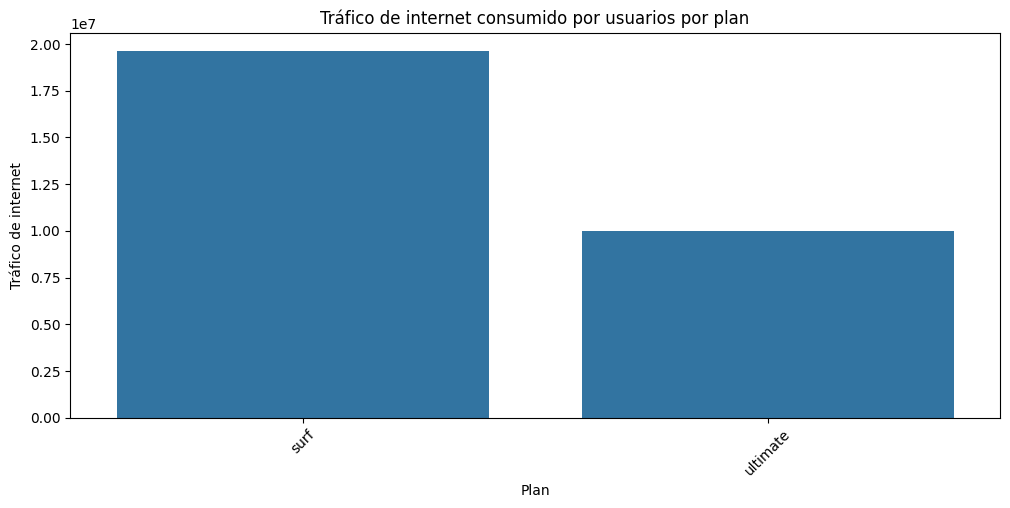

In [35]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

internet_traffic_amount = user_consumption_per_month.groupby("plan")["internet_traffic"].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=internet_traffic_amount, x="plan", y="internet_traffic")
plt.title("Tráfico de internet consumido por usuarios por plan")
plt.xlabel("Plan")
plt.ylabel("Tráfico de internet")
plt.xticks(rotation=45)
plt.show()


Estadísticas del número de mensajes
       plan       mean          var        std
0      surf  39.489831  1044.217878  32.314360
1  ultimate  46.455959  1084.393818  32.930135



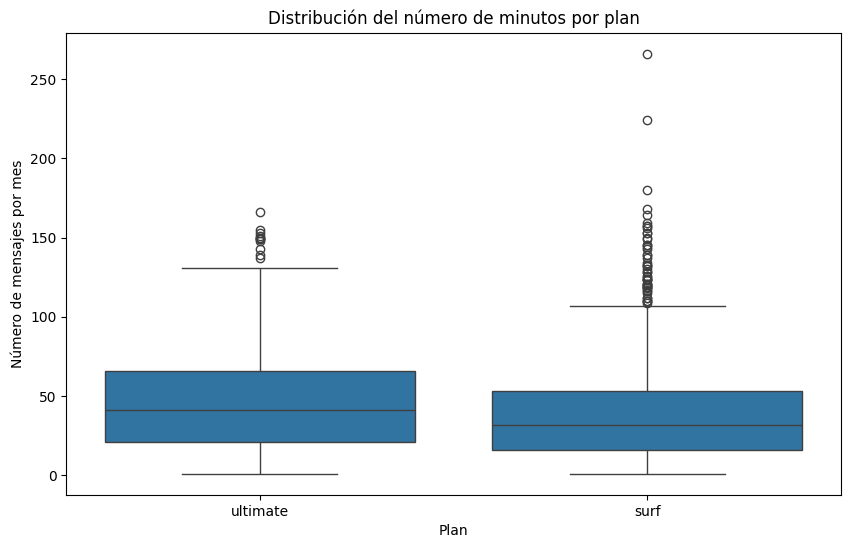

In [36]:
messages_stats = (
    user_consumption_per_month
        .groupby("plan")["number_messages"]
        .agg(["mean", "var", "std"])
        .reset_index()
)

print("Estadísticas del número de mensajes")
print(messages_stats)
print()

plt.figure(figsize=(10, 6))
sns.boxplot(data=user_consumption_per_month, x="plan", y="number_messages")
plt.title("Distribución del número de minutos por plan")
plt.xlabel("Plan")
plt.ylabel("Número de mensajes por mes")
plt.show()

En el análisis del comportamiento de los usuarios respecto a los mensajes, observé:
- Los usuarios del plan Surf en promedio no rebasane el límite de mensajes.
- Los usuarios del plan Ultimate en promedio se mantienen en el rango del plan Surf a pesar de que tiene un número mayor de mensajes incluidos.
- El promedio del número de mensajes que utilizan los usuarios es de 39 mientras que Ultimate es de 46 es de esperar ya que Ultimate tiene más cantidad de mensajes incluidos.
- Los usuarios del plan Ultimate usan más mensajes pero no por mucho.
- Los usuarios del plan Ultimate tienen una caja más grande, por lo que se puede interpretar como mayor diversidad de uso.
- Los usuarios del plan Surf tiene más outliers superiores, por lo que se pude traduce en muchos usuarios que sobrepasan por mucho el uso de mensajes del limite del plan.


### Internet

        plan  month  internet_traffic
0       surf      1       7896.000000
1       surf      2       9311.600000
2       surf      3      12396.625000
3       surf      4      11851.200000
4       surf      5      14851.056604
5       surf      6      15565.657143
6       surf      7      16708.505618
7       surf      8      17161.924370
8       surf      9      16492.598639
9       surf     10      17406.325967
10      surf     11      16300.188073
11      surf     12      17968.313008
12  ultimate      1       6953.333333
13  ultimate      2      17335.600000
14  ultimate      3      23836.285714
15  ultimate      4      14285.750000
16  ultimate      5      16993.095238
17  ultimate      6      15451.108108
18  ultimate      7      16499.531915
19  ultimate      8      17977.385965
20  ultimate      9      16410.394366
21  ultimate     10      17512.056818
22  ultimate     11      17323.519608
23  ultimate     12      18267.120000



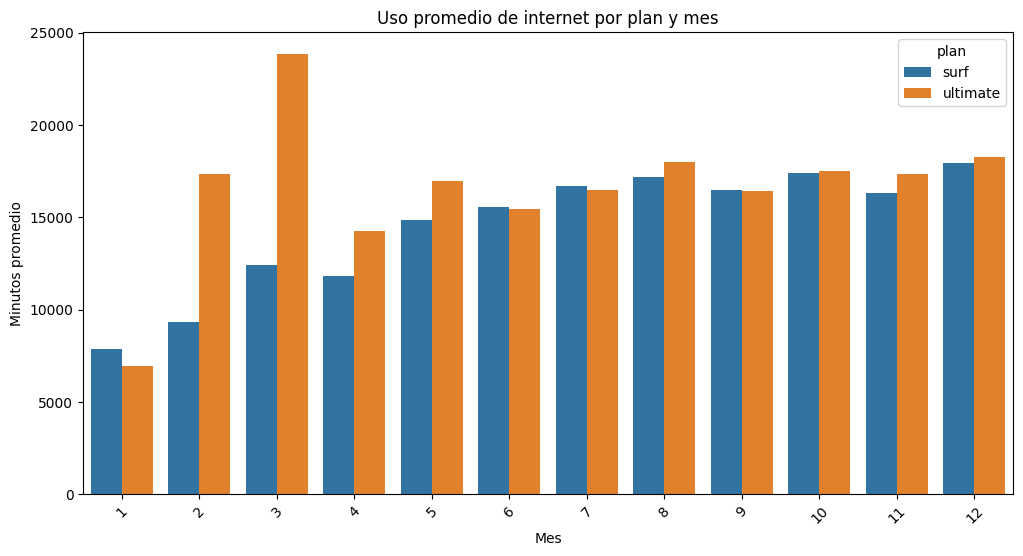

In [37]:
avg_internet = (
    user_consumption_per_month
        .groupby(["plan", "month"])["internet_traffic"]
        .mean()
        .reset_index()
)

print(avg_internet)
print()

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_internet, x="month", y="internet_traffic", hue="plan")
plt.title("Uso promedio de internet por plan y mes")
plt.xlabel("Mes")
plt.ylabel("Minutos promedio")
plt.xticks(rotation=45)
plt.show()

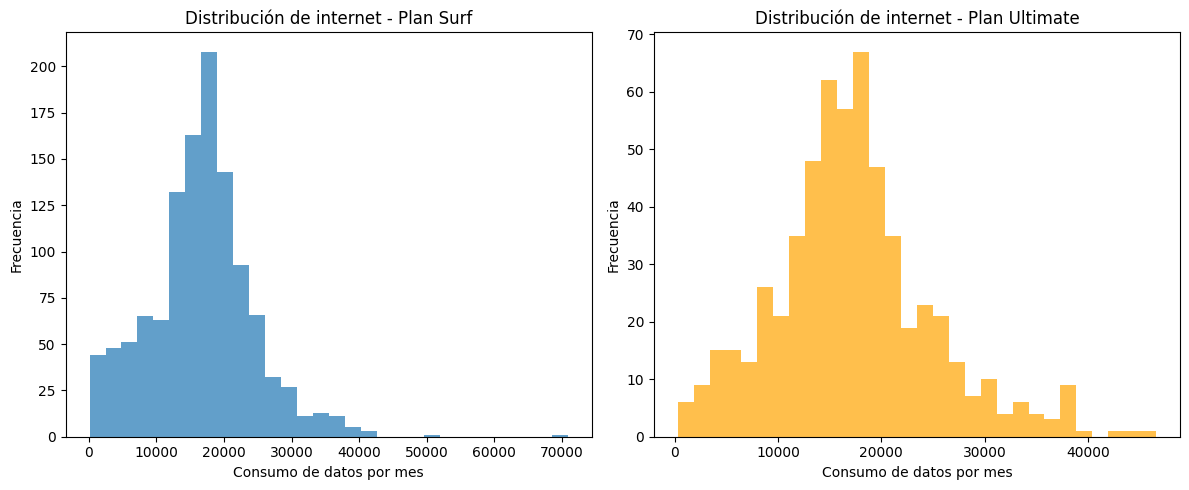

In [38]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
surf_internet = user_consumption_per_month[
    user_consumption_per_month["plan"] == "surf"
]["internet_traffic"]
plt.hist(surf_internet, bins=30, alpha=0.7, label="Surf")
plt.title("Distribución de internet - Plan Surf")
plt.xlabel("Consumo de datos por mes")
plt.ylabel("Frecuencia")

plt.subplot(1, 2, 2)

ultimate_internet = user_consumption_per_month[
    user_consumption_per_month["plan"] == "ultimate"
]["internet_traffic"]
plt.hist(ultimate_internet, bins=30, alpha=0.7, label="Ultimate", color="orange")
plt.title("Distribución de internet - Plan Ultimate")
plt.xlabel("Consumo de datos por mes")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

Estadísticas del consumo de internet por plan: 
       plan      mean          var      std
0      surf  16629.00  59510011.99  7714.27
1  ultimate  17250.93  59089865.27  7686.99


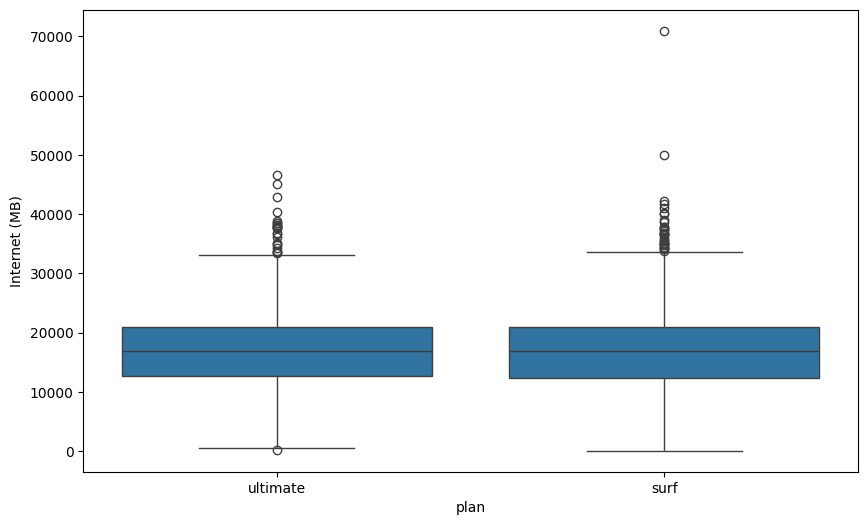

In [39]:
internet_stats = user_consumption_per_month.groupby("plan")["internet_traffic"] \
    .agg(["mean", "var", "std"]) \
    .round(2) \
    .reset_index()
print("Estadísticas del consumo de internet por plan: ")
print(internet_stats)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=user_consumption_per_month,
    x="plan",
    y="internet_traffic"
)
plt.xlabel("plan")
plt.ylabel("Internet (MB)")

plt.show()

En el análisis del comportamiento de los usuarios respecto al uso de internet, observé:
- Los usuarios del plan Surf en promedio, a la mitad del año comienzan a super sus limites del mes.
- Los usuarios del plan Ultimate en promedio no superan su limite de internet.
- Los usuarios del plan Ultimate en promedio usan considerablemente más los meses de febrero y marzo, comportamiento que se ve raro ya que durante el año van incrementando su uso conforme avanzan los meses.
- Algunos usuarios del plan Surf han usado hasta 70000 datos sobrepasando por mucho el limite de datos, siendo el límite 15000. En cambio los usuarios del plan Ultimate en promedio han respetado su límite de datos manteniendose dentro de 50000.
- Los usuarios de ambos planes tiene usos similares de datos.

## Ingreso

        plan  month       sum       mean  count
0       surf      1     20.00  20.000000      1
1       surf      2    119.57  23.914000      5
2       surf      3    616.65  38.540625     16
3       surf      4   1420.70  40.591429     35
4       surf      5   2695.43  50.857170     53
5       surf      6   3645.67  52.081000     70
6       surf      7   5500.77  61.806404     89
7       surf      8   7661.59  64.383109    119
8       surf      9   8387.94  57.060816    147
9       surf     10  11811.67  65.257845    181
10      surf     11  12451.42  57.116606    218
11      surf     12  16919.28  68.777561    246
12  ultimate      1    210.00  70.000000      3
13  ultimate      2    350.00  70.000000      5
14  ultimate      3    546.00  78.000000      7
15  ultimate      4   1169.00  73.062500     16
16  ultimate      5   1491.00  71.000000     21
17  ultimate      6   2667.00  72.081081     37
18  ultimate      7   3402.00  72.382979     47
19  ultimate      8   4130.00  72.456140

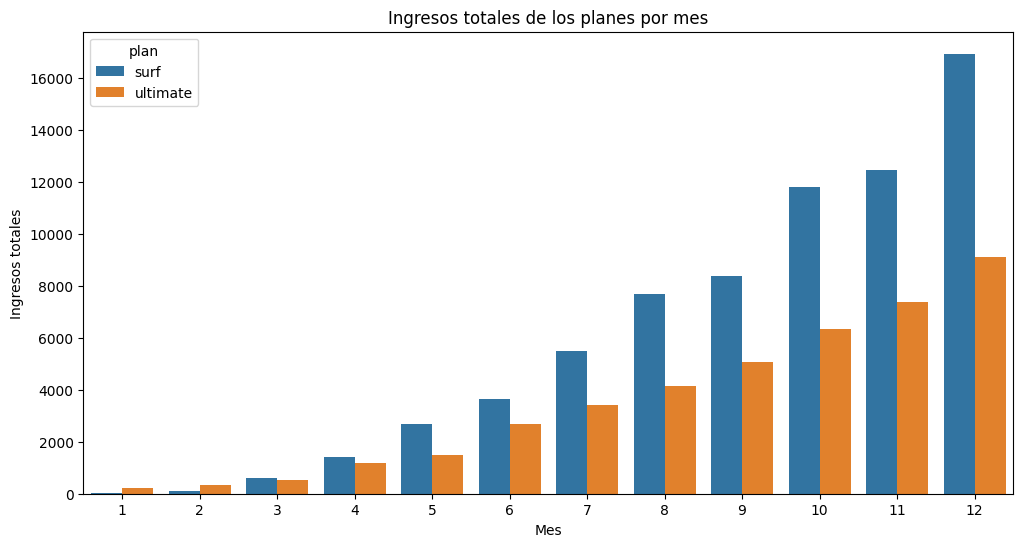

In [40]:
income_total = user_consumption_per_month.groupby(["plan", "month"])["income"] \
    .agg(["sum", "mean", "count"]) \
    .reset_index()

print(income_total, "\n")

plt.figure(figsize=(12, 6))
sns.barplot(data=income_total, x="month", y="sum", hue="plan")
plt.title("Ingresos totales de los planes por mes")
plt.xlabel("Mes")
plt.ylabel("Ingresos totales")

plt.show()

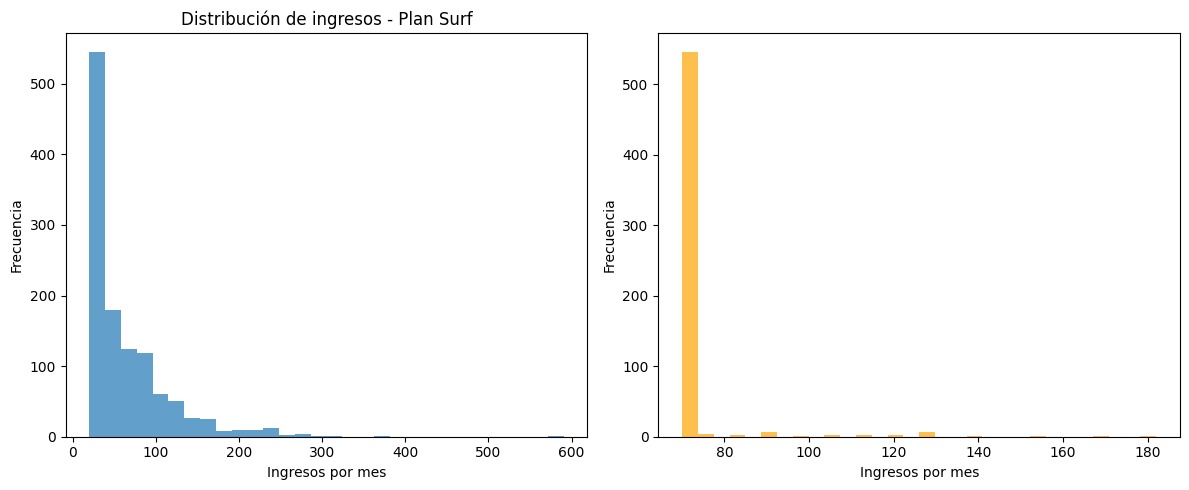

In [41]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
surf_income = user_consumption_per_month[
    user_consumption_per_month["plan"] == "surf"
]["income"]
plt.hist(surf_income, bins=30, alpha=0.7, label="Surf")
plt.title("Distribución de ingresos - Plan Surf")
plt.xlabel("Ingresos por mes")
plt.ylabel("Frecuencia")

plt.subplot(1, 2, 2)
ultimate_income = user_consumption_per_month[
    user_consumption_per_month["plan"] == "ultimate"
]["income"]
plt.hist(ultimate_income, bins=30, alpha=0.7, label="Ultimate", color="orange")
plt.xlabel("Ingresos por mes")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

Estadísticas de los ingresos por plan: 

       plan   mean      var    std
0      surf  60.38  2869.22  53.57
1  ultimate  72.25   121.76  11.03


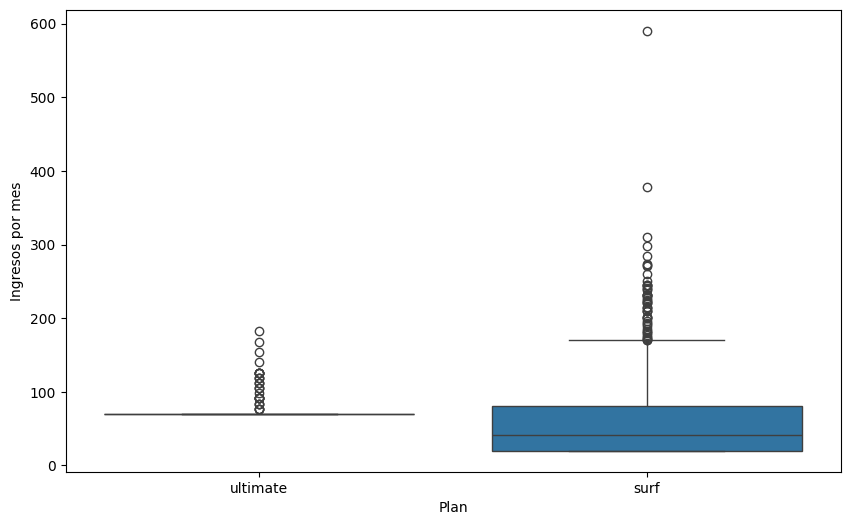

In [42]:
income_stats = user_consumption_per_month.groupby("plan")["income"] \
    .agg(["mean", "var", "std"]) \
    .round(2) \
    .reset_index()

print("Estadísticas de los ingresos por plan: \n")
print(income_stats)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=user_consumption_per_month,
    x="plan",
    y="income",
)
plt.xlabel("Plan")
plt.ylabel("Ingresos por mes")

plt.show()

En el análisis sobre los ingresos de los planes, observé:
- Observe que algunos usuarios del plan Surf en promedio por exceder mucho sus límites y se acercan mucho al precio de un plan Ultimate.
- Los usuarios del plan Ultimate en promedio rondan alrededor del límite, no se exceden considerablemente.
- Los usuarios del plan Surf tienden a superar el límite de plan gastando incluso muchos más que si tuvieran un plan Ultimate mientras que los usuarios del plan Ultimate no tiene incomvenientes con los beneficios de su plan.
- También observo que el comportamiento de los usuarios del plan Surf es muy variable, mientras que los usuarios del plan Ultimate son más consistentes.

## Prueba las hipótesis estadísticas

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]
H0: Los ingresos promedio de los usuarios de ambos planes son iguales.
H1: Los ingresos promedio de los usuarios del plan Surf son diferentes al del plan Ultimate. 

Prueba estadísticas a utilizar: prueba t de Student para muestras independientes.
Para esta prueba de hipótesis, seleccioné alpha = 0.05 (5%) como nivel de significancia crítica.

In [43]:
# Prueba las hipótesis

surf_income
ultimate_income
alpha = 0.05

results = st.ttest_ind(surf_income, ultimate_income, equal_var=False)

print("valor p: ", results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p:  4.825698250698308e-13
Rechazamos la hipótesis nula


H0: El ingreso promedio de los usuarios del área NY-NJ es igual al del resto de los usuarios.
H1: El ingreso promedio de los usuarios del área NY-NJ es diferente al del resto de los usuarios.

La prueba estadística a utilizar: prueba t de Student para muestras independientes.
Para esta prueba de hipótesis, seleccioné alpha = 0.05 (5%) como nivel de significancia crítica.

In [44]:
# Prueba las hipótesis
user_income = user_consumption_per_month.merge(users_df, on="user_id", how="left")

users_ny_nj = user_income[
    user_income["region"] == "NY-NJ-PA"
]["income"]
users_other = user_income[
    user_income["region"] != "NY-NJ-PA"
]["income"]

alpha = 0.05

results = st.ttest_ind(users_ny_nj, users_other)

print("Valor p: ", results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No debemos rechazar la hipótesis nula")


Valor p:  0.010594255333959619
Rechazamos la hipótesis nula


## Conclusión general

Conclusiones sobre el análisis del comportamiento de los usuarios:

1. El plan que genera más ingresos es el plan Surf devido a que los usuarios exceden el límite del plan.
2. Los usuarios del plan Ultimate satisfacen sus necesidades con los beneficios del plan. Normalmente no exceden sus límites.
3. Los usuarios del plan Surf llegan a pagar más que el costo de un plan Ultimate por requirir más datos para navegación.
4. Los usuarios del plan Surf tiene una necesedad de datos, su plan no cubre lo que ellos requieren.
5. Los ingresos promedio de los usuarios claramente es muy diferente entre planeas como para decir que fue casualidad, por lo que realmente si existe un diferencia entre ambos planes posiblemente por la necesidad de más datos para navegación de los usuarios del plan Surf.
6. Las regiones que generán este grán incremento de ingresos posiblemente son usuarios de regiones diferentes a NY-NJ.